In [1]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path (works inside notebooks where __file__ is undefined)
ROOT = Path.cwd().resolve()
if (ROOT / 'src').exists():
    repo_root = ROOT
elif (ROOT.parent / 'src').exists():
    repo_root = ROOT.parent
else:
    # Fallback: go two levels up
    repo_root = ROOT.parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print(f"Using repo root: {repo_root}")

Using repo root: D:\git projects\certified-attribution-medical-imaging


In [2]:
from pathlib import Path
import json
import torch
from torchvision.utils import save_image
from src.certify.utils.generate_grid_dataset import _load_dataset, generate_grids, save_grid_dataset

dataset_name = 'isic'
split = 'val'
data_root = repo_root / 'data/raw'  # absolute path from detected repo_root
num_grids = 32  # adjust as needed
scale = 2
target_cell = 0  # top-left cell is the target class
target_size = 224
allow_repeats = False


In [3]:

 # Outputs
pt_out = repo_root / f'data/raw/grid/{dataset_name}/{split}/grid.pt'
png_root = repo_root / f'data/raw/grid/{dataset_name}/{split}'
png_dir = png_root / 'images'
labels_path = png_root / 'labels.json'
meta_path = png_root / 'metadata.json'
raw_labels = data_root / dataset_name / split / 'labels.json'
processed_labels = repo_root / f'data/processed/{dataset_name}/{split}/labels.json'


In [4]:
# Ensure labels.json exists in data/raw/<dataset>/<split> (copy from processed if available)
import shutil
if not raw_labels.exists():
    if processed_labels.exists():
        raw_labels.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(processed_labels, raw_labels)
        print(f"Copied labels.json from {processed_labels} to {raw_labels}")
    else:
        raise FileNotFoundError(f"labels.json not found in raw or processed: {raw_labels} | {processed_labels}")
else:
    print(f"Found labels.json in raw: {raw_labels}")

Found labels.json in raw: D:\git projects\certified-attribution-medical-imaging\data\raw\isic\val\labels.json


In [5]:
# Generate grid payload (.pt) - skip if already exists
if pt_out.exists():
    print(f'Grid payload already exists at {pt_out}, skipping generation...')
    payload = torch.load(pt_out)
else:
    from torchvision import transforms
    from src.datasets.isic import ISICDataset
    pil_safe_transform = transforms.Compose([
        transforms.Resize((target_size, target_size)),
        transforms.ToTensor(),
    ])
    ds = ISICDataset(root_dir=str(data_root / dataset_name), split=split, transform=pil_safe_transform, target_size=(target_size, target_size))
    payload = generate_grids(ds, num_grids=num_grids, scale=scale, target_cell=target_cell, allow_repeats=allow_repeats)
    pt_out.parent.mkdir(parents=True, exist_ok=True)
    save_grid_dataset(payload, pt_out)
    print(f'Saved tensor payload → {pt_out}')
print({k: payload[k] for k in ['images', 'cell_classes', 'target_classes']})

Grid payload already exists at D:\git projects\certified-attribution-medical-imaging\data\raw\grid\isic\val\grid.pt, skipping generation...
{'images': tensor([[[[0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.6549, 0.6510, 0.6588,  ..., 0.2078, 0.2078, 0.1961],
          [0.6431, 0.6471, 0.6510,  ..., 0.2078, 0.2039, 0.1882],
          [0.6392, 0.6431, 0.6471,  ..., 0.2118, 0.2000, 0.1843]],

         [[0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.6510, 0.6471, 0.6431,  ..., 0.1608, 0.1529, 0.1412],
          [0.6392, 0.6392, 0.6392,  ..., 0.1529, 0.1451, 0.1373],
          [0.6275, 0.6275, 0.6275,  ..., 0.1490, 0.1412, 0.1333]],

         [[0.0039, 0.00

In [6]:
# Export PNGs + labels/metadata - skip if already exists
if labels_path.exists() and meta_path.exists() and png_dir.exists():
    print(f'Grid PNGs and metadata already exist, skipping export...')
    print(f'labels.json → {labels_path}')
    print(f'metadata.json → {meta_path}')
    with open(labels_path) as f:
        labels = json.load(f)
    with open(meta_path) as f:
        metadata = json.load(f)
else:
    png_dir.mkdir(parents=True, exist_ok=True)
    labels = {}
    metadata = {
        'cell_classes': payload['cell_classes'].tolist(),
        'source_indices': payload['source_indices'].tolist(),
        'target_classes': payload['target_classes'].tolist(),
        'target_cell': payload['target_cell'],
        'scale': payload['scale'],
        'image_size': payload['image_size'],
        'dataset': payload['dataset'],
        'split': payload['split'],
        'num_classes': payload['num_classes'],
        'class_names': payload.get('class_names'),
    }
    for idx, img in enumerate(payload['images']):
        # Ensure tensor for save_image
        if hasattr(img, 'permute') and isinstance(img, torch.Tensor):
            tensor_img = img
        else:
            tensor_img = torch.tensor(img)
        fname = f'grid_{idx:04d}.png'
        save_image(tensor_img, png_dir / fname)
        labels[fname] = int(payload['target_classes'][idx])  # classifier label is target class
    
    with open(labels_path, 'w') as f:
        json.dump(labels, f)
    with open(meta_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f'Saved {len(labels)} grids as PNG → {png_dir}')
    print(f'labels.json → {labels_path}')
    print(f'metadata.json → {meta_path}')

Grid PNGs and metadata already exist, skipping export...
labels.json → D:\git projects\certified-attribution-medical-imaging\data\raw\grid\isic\val\labels.json
metadata.json → D:\git projects\certified-attribution-medical-imaging\data\raw\grid\isic\val\metadata.json


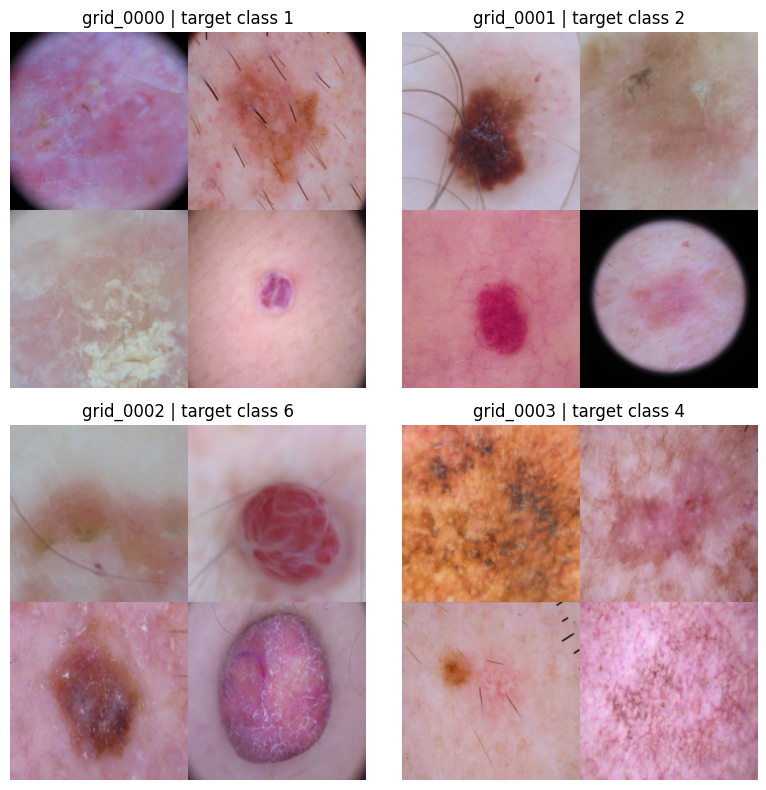

In [7]:
# Quick visualization of first 4 grids
import matplotlib.pyplot as plt
import math
n_show = 4
rows = math.ceil(n_show / 2)
fig, axes = plt.subplots(rows, 2, figsize=(8, 4*rows))
axes = axes.flatten()
for i in range(n_show):
    axes[i].imshow(payload['images'][i].permute(1,2,0).clamp(0,1))
    axes[i].set_title(f'grid_{i:04d} | target class {int(payload['target_classes'][i])}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Grad-CAM on 2 grid samples (mock certification output)
import numpy as np
import pickle
import torch
from torchvision import transforms
from PIL import Image
from src.models.factory import get_model
from src.xai.attribution_unified import GradCAMUnified
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
grid_root = repo_root / 'data/raw/grid/isic/val'
img_dir = grid_root / 'images'
labels_path = grid_root / 'labels.json'
checkpoint_dir = repo_root / 'notebooks/output/checkpoints/isic/resnet18'
ckpt_path = checkpoint_dir / 'final_model.pt'

with open(labels_path) as f:
    labels = json.load(f)
samples = sorted(labels.items())[:2]
print(f"Using samples: {[s[0] for s in samples]}")

# Load model + Grad-CAM (match checkpoint head: 8 classes)
model, cfg = get_model('resnet18', num_classes=8, pretrained=False, device=device)
state = torch.load(ckpt_path, map_location=device)
if isinstance(state, dict):
    if 'model_state_dict' in state:
        state = state['model_state_dict']
    elif 'state_dict' in state:
        state = state['state_dict']
state = {k.replace('module.', ''): v for k, v in state.items()}
missing, unexpected = model.load_state_dict(state, strict=False)
print(f"Loaded checkpoint with missing={len(missing)}, unexpected={len(unexpected)} (ignored)")
model.eval()
target_layer = model.layer4[-1].conv2
gradcam = GradCAMUnified(model, target_layer, device=device)

preprocess = transforms.Compose([
    transforms.Resize((cfg.input_size, cfg.input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cfg.mean, std=cfg.std),
])

entries = {50: [], 25: [], 5: []}

for idx, (fname, target_cls) in enumerate(samples):
    img = Image.open(img_dir / fname).convert('RGB')
    img_size = img.size  # (W, H)
    input_tensor = preprocess(img)
    heatmap = gradcam.attribute(input_tensor, int(target_cls))
    
    # Upsample heatmap to full image resolution (grid images are 448x448)
    heatmap_tensor = torch.from_numpy(heatmap).unsqueeze(0).unsqueeze(0).float()
    heatmap_upsampled = F.interpolate(heatmap_tensor, size=img_size[::-1], mode='bilinear', align_corners=False)
    heatmap_full = heatmap_upsampled[0, 0].numpy()
    
    flat = heatmap_full.flatten()
    for k in entries:
        thresh = np.percentile(flat, 100 - k)
        cmap = (heatmap_full >= thresh).astype(np.int8)
        entries[k].append({'image_idx': idx, 'results': {'certified_map': cmap}})
    print(f"Done {fname}: target {target_cls}, heatmap shape {heatmap_full.shape}")

cert_results = {'resnet18': {'GradCAM': entries}}
cert_out = repo_root / 'notebooks/output/certification/grid/isic/resnet18_gradcam_mock.pkl'
cert_out.parent.mkdir(parents=True, exist_ok=True)
with open(cert_out, 'wb') as f:
    pickle.dump(cert_results, f)
print(f"Saved mock certification results -> {cert_out}")

Using samples: ['grid_0000.png', 'grid_0001.png']


d:\git projects\certified-attribution-medical-imaging\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\git projects\certified-attribution-medical-imaging\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded checkpoint with missing=0, unexpected=0 (ignored)


d:\git projects\certified-attribution-medical-imaging\venv\Lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


[DEBUG] GradCAM fix active: hooks clone tensors
Done grid_0000.png: target 1, heatmap shape (448, 448)
[DEBUG] GradCAM fix active: hooks clone tensors
Done grid_0001.png: target 2, heatmap shape (448, 448)
Saved mock certification results -> D:\git projects\certified-attribution-medical-imaging\notebooks\output\certification\grid\isic\resnet18_gradcam_mock.pkl


In [9]:
# Localization evaluation on Grad-CAM mock certification
from src.certify.eval.localization import LocalizationEvaluator

loc_output_dir = repo_root / 'notebooks/output/eval/localization/grid/isic/resnet18'
loc_output_dir.mkdir(parents=True, exist_ok=True)

loc_eval = LocalizationEvaluator(
    dataset_name='isic',
    model_name='resnet18',
    checkpoint_dir=repo_root / 'notebooks/output/checkpoints/isic',
    device=device,
)
loc_results = loc_eval.evaluate_batch(
    cert_results_pkl=cert_out,
    dataset=None,
    output_dir=loc_output_dir,
    grid_metadata_json=grid_root / 'metadata.json',
)
loc_eval.save_results_json(loc_results, loc_output_dir / 'localization_results.json')
loc_eval.plot_results(loc_results, loc_output_dir / 'figures')
loc_results

  Loading checkpoint: D:\git projects\certified-attribution-medical-imaging\notebooks\output\checkpoints\isic\resnet18\final_model.pt
  ✓ Built 32 masks from grid metadata
  Evaluating GradCAM...
  ✓ Saved results to D:\git projects\certified-attribution-medical-imaging\notebooks\output\eval\localization\grid\isic\resnet18\localization_results.json
  ✓ Saved localization figure to D:\git projects\certified-attribution-medical-imaging\notebooks\output\eval\localization\grid\isic\resnet18\figures\localization_gridpg.png


{'GradCAM': defaultdict(dict,
             {50: {'mean_gridpg': 0.3329583459145572,
               'std_gridpg': 0.16105345114414907,
               'num_images': 2},
              25: {'mean_gridpg': 0.4377927735446109,
               'std_gridpg': 0.42699079650379457,
               'num_images': 2},
              5: {'mean_gridpg': 0.5, 'std_gridpg': 0.5, 'num_images': 2}})}

d:\git projects\certified-attribution-medical-imaging\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\git projects\certified-attribution-medical-imaging\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
d:\git projects\certified-attribution-medical-imaging\venv\Lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(a

[DEBUG] GradCAM fix active: hooks clone tensors
[DEBUG] GradCAM fix active: hooks clone tensors


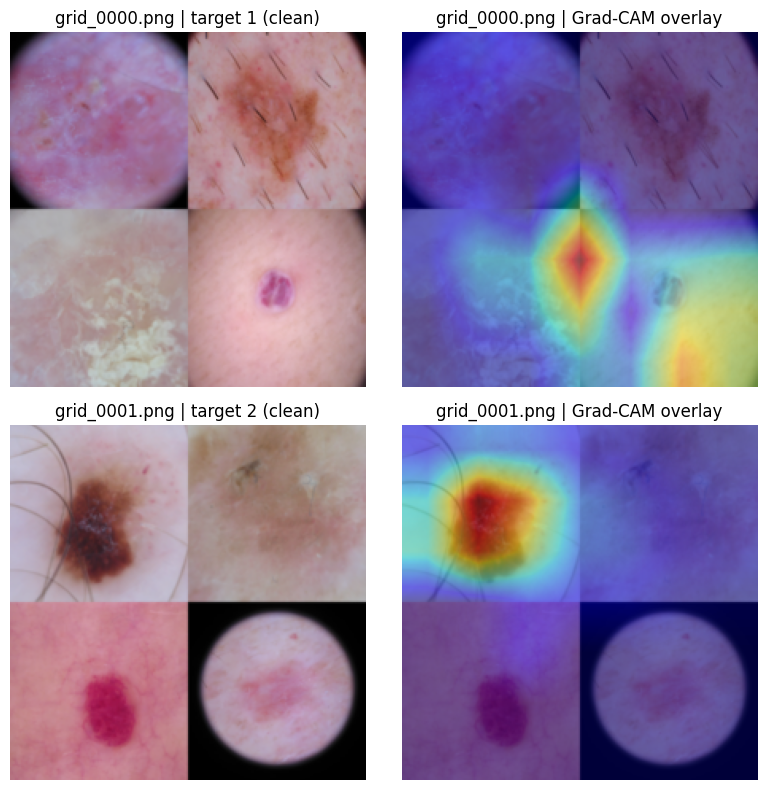

Saved Grad-CAM overlays to D:\git projects\certified-attribution-medical-imaging\notebooks\output\attributions_viz\grid\isic\resnet18/gradcam_comparison.png


In [10]:
# Visualize Grad-CAM heatmaps for the same 2 grid samples
import matplotlib.pyplot as plt
from matplotlib import cm
import torch.nn.functional as F

viz_dir = repo_root / 'notebooks/output/attributions_viz/grid/isic/resnet18'
viz_dir.mkdir(parents=True, exist_ok=True)

# Recompute Grad-CAM to visualize (uses same samples and model settings)
model, cfg = get_model('resnet18', num_classes=8, pretrained=False, device=device)
state = torch.load(ckpt_path, map_location=device)
if isinstance(state, dict):
    if 'model_state_dict' in state:
        state = state['model_state_dict']
    elif 'state_dict' in state:
        state = state['state_dict']
state = {k.replace('module.', ''): v for k, v in state.items()}
model.load_state_dict(state, strict=False)
model.eval()
target_layer = model.layer4[-1].conv2
gradcam = GradCAMUnified(model, target_layer, device=device)

def overlay_heatmap(img_tensor, heatmap_np, alpha=0.45):
    # img_tensor is normalized; unnormalize for display
    img = img_tensor.clone()
    for c, m, s in zip(range(3), cfg.mean, cfg.std):
        img[c] = img[c] * s + m
    img = img.clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    heat = (heatmap_np - heatmap_np.min()) / (heatmap_np.max() - heatmap_np.min() + 1e-8)
    heat_color = cm.jet(heat)[..., :3]
    overlay = (1 - alpha) * img + alpha * heat_color
    return img, overlay

fig, axes = plt.subplots(len(samples), 2, figsize=(8, 4*len(samples)))
if len(samples) == 1:
    axes = np.expand_dims(axes, 0)
axes = axes.reshape(len(samples), 2)

for row, (fname, target_cls) in enumerate(samples):
    img_pil = Image.open(img_dir / fname).convert('RGB')
    img_size = img_pil.size  # (W, H) - original grid size (448, 448)
    input_tensor = preprocess(img_pil)
    heatmap = gradcam.attribute(input_tensor, int(target_cls))
    
    # Upsample heatmap to preprocessed image size (224x224)
    heatmap_tensor = torch.from_numpy(heatmap).unsqueeze(0).unsqueeze(0).float()
    heatmap_upsampled = F.interpolate(heatmap_tensor, size=(224, 224), mode='bilinear', align_corners=False)
    heatmap_full = heatmap_upsampled[0, 0].numpy()
    
    img_vis, overlay = overlay_heatmap(input_tensor, heatmap_full)
    axes[row, 0].imshow(img_vis)
    axes[row, 0].set_title(f'{fname} | target {target_cls} (clean)')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(f'{fname} | Grad-CAM overlay')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig(viz_dir / 'gradcam_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved Grad-CAM overlays to {viz_dir}/gradcam_comparison.png')